In [23]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt


# Step 1: Load the data
df = pd.read_csv('./data/car_price_dataset.csv')

df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


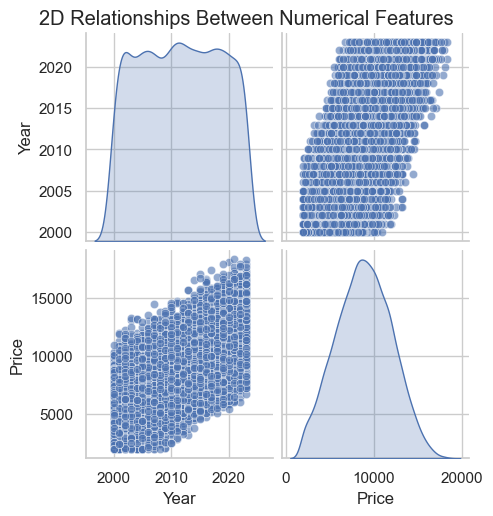

In [26]:
# Set aesthetic style
sns.set(style="whitegrid")

# Focus on a few selected numerical columns for pairplot
num_features = ['Year','Price']

# Plot pairplot for numerical columns
sns.pairplot(df[num_features], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle("2D Relationships Between Numerical Features", y=1.02)
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import pandas as pd
import numpy as np

def find_closest_match(data, user_input):
    numeric = ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Price']
    categorical = ['Brand', 'Model', 'Fuel_Type', 'Transmission']

    # Split input into numeric/categorical
    input_numeric = {k: v for k, v in user_input.items() if k in numeric}
    input_categorical = {k: v for k, v in user_input.items() if k in categorical}

    # Filter dataset by only selected features
    features = pd.DataFrame()
    input_vector = pd.DataFrame()

    # Handle numeric
    if input_numeric:
        features = data[list(input_numeric.keys())].copy()
        input_vector = pd.DataFrame([input_numeric])

        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
        input_scaled = scaler.transform(input_vector)

        features = pd.DataFrame(features_scaled, columns=input_numeric.keys())
        input_vector = pd.DataFrame(input_scaled, columns=input_numeric.keys())

    # Handle categorical
    if input_categorical:
        cat_df = data[list(input_categorical.keys())].copy()
        input_cat_df = pd.DataFrame([input_categorical])

        encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
        encoded = encoder.fit_transform(cat_df)
        input_encoded = encoder.transform(input_cat_df)

        cat_feature_names = encoder.get_feature_names_out(input_categorical.keys())

        encoded_df = pd.DataFrame(encoded, columns=cat_feature_names)
        input_encoded_df = pd.DataFrame(input_encoded, columns=cat_feature_names)
        # Combine with numeric
        features = pd.concat([features.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
        input_vector = pd.concat([input_vector.reset_index(drop=True), input_encoded_df.reset_index(drop=True)], axis=1)

    # Run DBSCAN on full dataset for context
    full_features = data[numeric + categorical]
    full_features_encoded = pd.get_dummies(full_features, drop_first=True)
    scaler_full = StandardScaler()
    full_scaled = scaler_full.fit_transform(full_features_encoded)

    db = DBSCAN(eps=3, min_samples=1)
    clusters = db.fit_predict(full_scaled)
    data['cluster'] = clusters

    # Now compute distance in reduced (input-based) space
    # Make sure the feature set in input_vector matches feature columns
    cluster_label = clusters[np.argmin(cdist(features.values, input_vector.values))]
    cluster_indices = data[data['cluster'] == cluster_label].index
    cluster_subset = features.iloc[cluster_indices]

    dists = cdist(cluster_subset.values, input_vector.values)
    closest_index = cluster_indices[np.argmin(dists)]

    return data.loc[closest_index]


In [19]:
user_input = {
    "Price": 12000  # Just price
}


closest_car = find_closest_match(df, user_input)
print(closest_car)

Brand           Volkswagen
Model                 Golf
Year                  2021
Engine_Size            1.4
Fuel_Type           Petrol
Transmission     Automatic
Mileage              64978
Doors                    5
Owner_Count              2
Price                12000
cluster                  4
Name: 4545, dtype: object
